# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


#**Credit Risk Dataset**

##**Deskripsi Dataset**
Dataset ini berisi simulasi data dari biro kredit yang dirancang khusus untuk keperluan analisis risiko kredit dan pembuatan model *machine learning* (*credit scoring*). Fokus utama dari dataset ini adalah memprediksi kemampuan bayar calon nasabah—apakah mereka berpotensi lancar atau mengalami gagal bayar (*default*).

Data ini berformat CSV (`credit_risk_dataset.csv`) dengan ukuran sekitar 1.8 MB dan terdiri dari 12 kolom (fitur). Di dalamnya memuat informasi penting seperti:
* **Profil Peminjam:** Usia (`person_age`), pendapatan tahunan (`person_income`), status kepemilikan rumah (`person_home_ownership`), dan lama pengalaman kerja (`person_emp_length`).
* **Detail Pinjaman:** Tujuan pinjaman (`loan_intent`), nilai peringkat pinjaman (`loan_grade`), jumlah pinjaman (`loan_amnt`), dan suku bunga (`loan_int_rate`).
* **Target Prediksi:** Status pinjaman (`loan_status`) di mana `0` berarti tidak gagal bayar dan `1` berarti gagal bayar.


## **Sumber Data**
Dataset ini diambil secara publik melalui platform Kaggle:
* **Sumber Data:**   [Kaggle - Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [42]:
import pandas as pd
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [43]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
df = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')

In [45]:
# Menampilkan 5 baris pertama
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [46]:
# Melihat informasi struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [47]:
sns.set_theme(style="whitegrid")

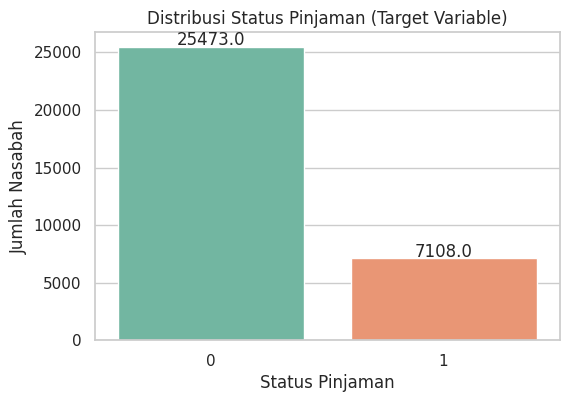

In [48]:
# Mengecek Distribusi Variabel Target (loan_status)
# 0 = Non-Default (Aman), 1 = Default (Gagal Bayar)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='loan_status', hue='loan_status', palette='Set2', legend=False)
plt.title('Distribusi Status Pinjaman (Target Variable)')
plt.xlabel('Status Pinjaman')
plt.ylabel('Jumlah Nasabah')
# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

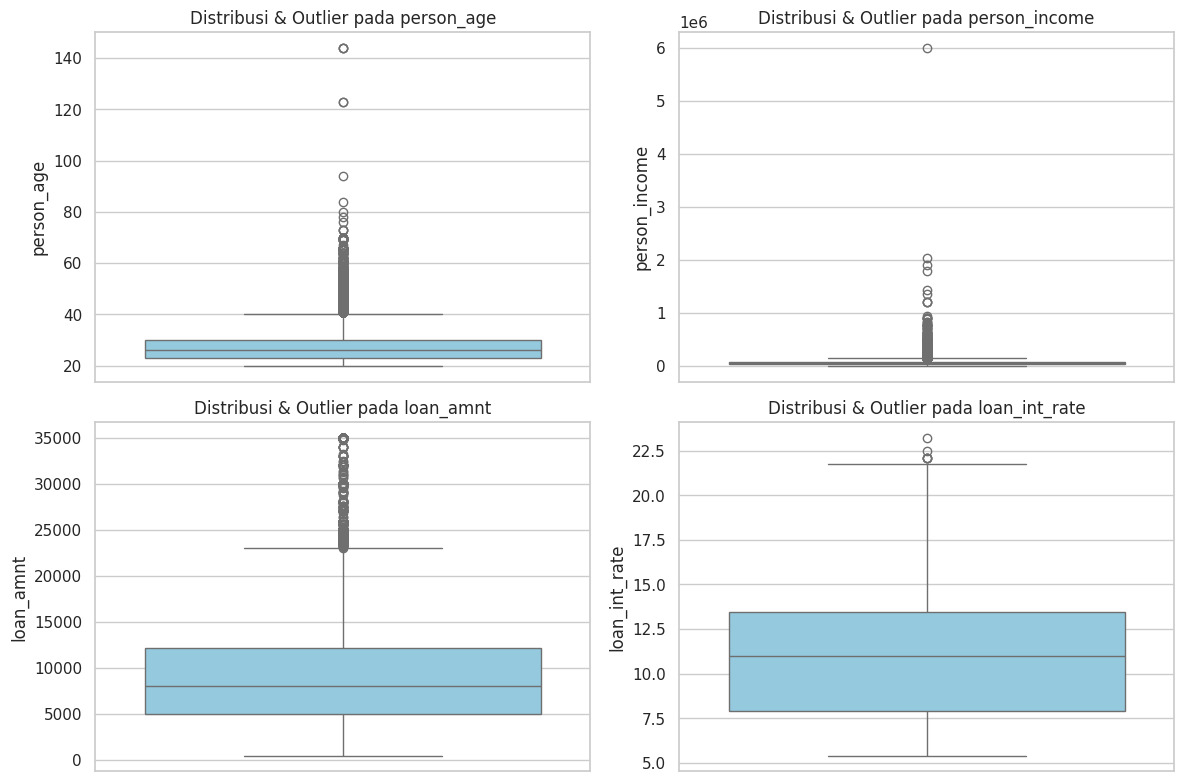

In [49]:
# Deteksi Outlier pada Variabel Numerik (Boxplot)
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribusi & Outlier pada {col}')
plt.tight_layout()
plt.show()

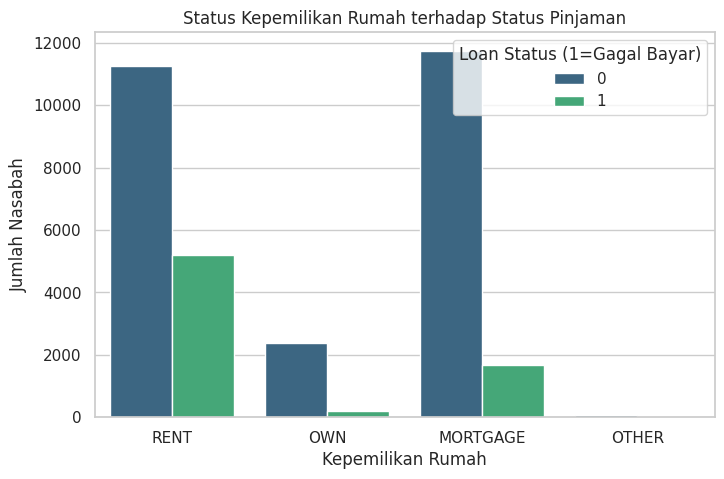

In [50]:
# Distribusi Variabel Kategorikal
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='person_home_ownership', hue='loan_status', palette='viridis')
plt.title('Status Kepemilikan Rumah terhadap Status Pinjaman')
plt.xlabel('Kepemilikan Rumah')
plt.ylabel('Jumlah Nasabah')
plt.legend(title='Loan Status (1=Gagal Bayar)')
plt.show()

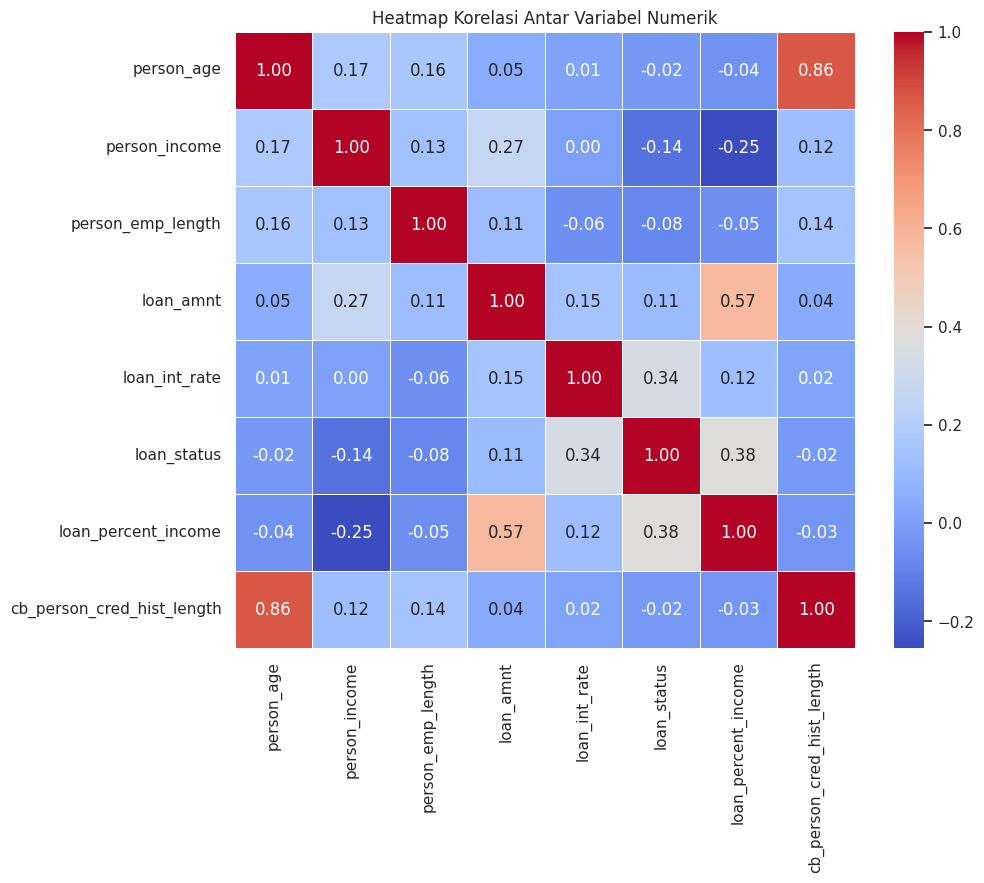

In [51]:
# Heatmap
plt.figure(figsize=(10, 8))
# Hanya menghitung korelasi untuk kolom numerik
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [52]:
# Menghapus Duplikat
df.drop_duplicates(inplace=True)

In [53]:
# Menangani Outlier
df_clean = df[(df['person_age'] <= 80) & (df['person_income'] <= 4000000)].copy()

In [54]:
# Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status'].reset_index(drop=True)

In [55]:
# Setup Pipeline Scikit-Learn
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [56]:
# Pipeline untuk data numerik (imputasi median + standarisasi)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [57]:
# Pipeline untuk data kategorikal (imputasi modus + One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [58]:
# Menggabungkan kedua pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [59]:
# Eksekusi Transformasi
X_transformed = preprocessor.fit_transform(X)

In [60]:
# Mengambil nama kolom baru
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

In [61]:
# Menggabungkan kembali menjadi DataFrame utuh
df_ready = pd.DataFrame(X_transformed, columns=all_feature_names)
df_ready['loan_status'] = y

In [62]:
# Menyimpan hasil otomatisasi menjadi file CSV
df_ready.to_csv('credit_risk_clean.csv', index=False)
print("Preprocessing selesai! Data siap latih disimpan sebagai credit_risk_clean.csv")

Preprocessing selesai! Data siap latih disimpan sebagai credit_risk_clean.csv


In [63]:
# Tampilkan sekilas hasilnya
df_ready.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_status
0,-0.924876,-0.131345,28.904116,4.018333,1.623420,3.929895,-0.692946,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
1,-1.086381,-1.071921,0.056492,-1.359199,0.040660,-0.657797,-0.939561,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,-0.440359,-1.071921,-0.921394,-0.647467,0.601761,3.742642,-0.692946,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,-0.763370,-0.007585,-0.187979,4.018333,1.367195,3.368137,-0.939561,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,-0.601865,-0.218929,0.789906,4.018333,1.055832,3.555389,-0.446332,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
